In [2]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import re
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from pathlib import Path
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch
import matplotlib as mpl
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# detector, runs and measure

In [162]:
detector = "V03421A"
measure = "ba_HS4_top_dlt"
run = "r001"

# path to HIT DATA

In [210]:
measurement_files = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/"
    f"generated/tier/hit/{detector}/c1/*"
))

print(*measurement_files, sep="\n")

/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_lat_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_lat_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_top_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS6_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS6_top_hvs
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/ba_HS4_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/bkg
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/co_HS5_top_hvs
/global/cfs/cdirs/m26

In [211]:
measurements = [
    os.path.basename(path)
    for path in measurement_files
]

print(measurements)

['am_HS1_lat_dlt', 'am_HS1_lat_ssh', 'am_HS1_top_dlt', 'am_HS1_top_ssh', 'am_HS6_top_dlt', 'am_HS6_top_hvs', 'ba_HS4_top_dlt', 'bkg', 'co_HS5_top_hvs', 'th_HS2_lat_psa', 'th_HS2_top_psa']


In [212]:
measure = measurements[0]

In [213]:
file_names = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/{detector}/c1/{measure}/char_data-{detector}-{measure}-{run}-*.lh5"
))

# for all the runs
# file_names = sorted(glob.glob(
   # f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/{detector}/c1/{measure}/*.lh5"
#))



In [215]:
data = lh5.read("hit", file_names)

In [216]:
df = data.view_as("pd")
df.head()

,AoE_Classifier,AoE_Corrected,AoE_Double_Sided_Cut,AoE_High_Side_Cut,AoE_Low_Cut,LQ_Classifier,LQ_Cut,bl_pileup_cut,bl_pileup_cut_classifier,cuspEmax_cal,...,tail_pileup_cut,tail_pileup_cut_classifier,timestamp,tp_0_est,trapEmax_cal,trapEmax_ctc_cal,trapEmax_noctc_cal,zacEmax_cal,zacEmax_ctc_cal,zacEmax_noctc_cal
0,-30.746280,0.621971,False,True,False,-17.547830,True,True,3.811887,71.844868,...,True,-0.051366,1.711308e+09,29184.0,71.774962,71.774962,71.770199,71.824615,71.824615,71.819373
1,-30.015306,0.631632,False,True,False,-2.453883,True,True,0.560378,167.239798,...,True,-1.085426,1.711308e+09,29120.0,167.299730,167.299730,167.287422,167.069218,167.069218,167.055699
2,-38.366725,0.515858,False,True,False,24.674972,False,True,-0.377195,351.890970,...,True,-0.873175,1.711308e+09,29264.0,351.977769,351.977769,351.955974,351.890591,351.890591,351.866622
3,-25.339563,0.692294,False,True,False,6.903950,False,True,0.589938,1044.361506,...,True,0.737249,1.711308e+09,29792.0,1044.704613,1044.704613,1044.683887,1043.726459,1043.726459,1043.703680
4,-48.965366,0.371234,False,True,False,235.770656,False,True,-0.320924,42.779875,...,True,-0.283412,1.711308e+09,28992.0,42.850288,42.853628,42.850288,42.528427,42.532073,42.528427


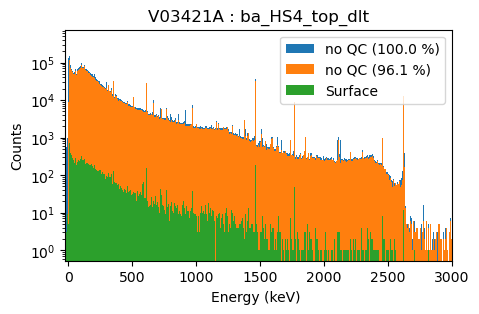

In [217]:
E_noQC = df["cuspEmax_ctc_cal"]
mask_clean = (
    ~df["is_discharge"]
    & df["is_positive_polarity_candidate"]
)
m_surface = (m & df["is_surface"])
E = df.loc[mask_clean, "cuspEmax_ctc_cal"]
bins = 1000
plt.figure(figsize=(5,3))
plt.hist(
    E_noQC,
    bins=bins,
    label=f"no QC ({len(E_noQC) * 100 / len(E_noQC):.1f} %)"
)
plt.hist(
    E,
    bins=bins,
    label=f"no QC ({len(E) * 100 / len(E_noQC):.1f} %)"
)

plt.hist(
     df.loc[m_surface, "cuspEmax_ctc_cal"],
    bins=bins,
    label=f"Surface"
)
plt.xlim(E.min(), 3000 )
plt.legend()
plt.title("V03421A : ba_HS4_top_dlt")
plt.xlabel("Energy (keV) ")
plt.ylabel("Counts")
plt.yscale('log')

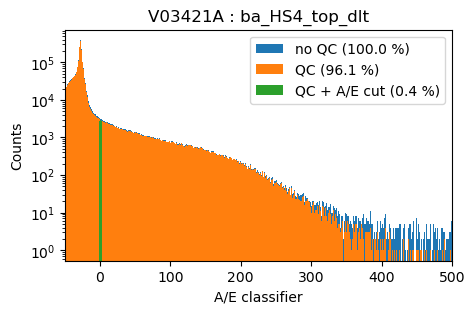

In [218]:
AoE_noQC = df["AoE_Classifier"]
mask_clean = (
    ~df["is_discharge"]
    & df["is_positive_polarity_candidate"]
)
AoE_hit = df.loc[mask_clean, "AoE_Classifier"]
m = (mask_clean & df["AoE_Double_Sided_Cut"])
AoE = df.loc[m, "AoE_Classifier"]
bins = 1000
plt.figure(figsize=(5,3))
plt.hist(
    AoE_noQC,
    bins=bins,
    range=(-50, 500),
    label=f"no QC ({len(AoE_noQC) * 100 / len(AoE_noQC):.1f} %)"
)
plt.hist(
    AoE_hit,
    bins=bins,
    range=(-50, 500),
    label=f"QC ({len(AoE_hit) * 100 / len(AoE_noQC):.1f} %)"
)
plt.hist(
    AoE,
    bins=bins,
    range=(-50, 500),
    label=f"QC + A/E cut ({len(AoE) * 100 / len(AoE_noQC):.1f} %)"
)
plt.xlim(-50, 500 )
plt.legend()
plt.title("V03421A : ba_HS4_top_dlt")
plt.xlabel("A/E classifier")
plt.ylabel("Counts")
plt.yscale('log')